# Phase 4 — Modèle ML : Prédiction du Nutri-Score
XGBoost multi-classe (A/B/C/D/E) à partir des valeurs nutritionnelles.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from xgboost import XGBClassifier

CSV_PROPRE = '../data/processed/openfoodfacts_clean.csv'
MODEL_PATH = Path('../models/nutriscore_xgb.pkl')
MODEL_PATH.parent.mkdir(exist_ok=True)

print('Imports OK')

Imports OK


## 1. Chargement et préparation du dataset ML

In [2]:
df = pd.read_csv(CSV_PROPRE, low_memory=False)

FEATURES = [
    'energy-kcal_100g', 'fat_100g', 'saturated-fat_100g',
    'sugars_100g', 'fiber_100g', 'proteins_100g', 'salt_100g'
]
TARGET = 'nutriscore_grade'

# Garder uniquement les lignes complètes (features + target)
cols_ml = [c for c in FEATURES if c in df.columns] + [TARGET]
df_ml = df[cols_ml].dropna()
df_ml = df_ml[df_ml[TARGET].isin(['a', 'b', 'c', 'd', 'e'])]

print(f'Dataset ML : {df_ml.shape[0]:,} produits')
print(f'Features   : {[c for c in FEATURES if c in df.columns]}')
print(f'\nRépartition des grades :')
print(df_ml[TARGET].value_counts().sort_index())

Dataset ML : 106,628 produits
Features   : ['energy-kcal_100g', 'fat_100g', 'saturated-fat_100g', 'sugars_100g', 'fiber_100g', 'proteins_100g', 'salt_100g']

Répartition des grades :
nutriscore_grade
a    33852
b    24243
c    30755
d     8582
e     9196
Name: count, dtype: int64


## 2. Encodage et split

In [3]:
features_utilisees = [c for c in FEATURES if c in df_ml.columns]

X = df_ml[features_utilisees]
y = df_ml[TARGET]

# Encodage : a=0, b=1, c=2, d=3, e=4
le = LabelEncoder()
le.fit(['a', 'b', 'c', 'd', 'e'])
y_enc = le.transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, random_state=42, stratify=y_enc
)

print(f'Train : {X_train.shape[0]:,} | Test : {X_test.shape[0]:,}')

Train : 85,302 | Test : 21,326


## 3. Entraînement XGBoost

In [4]:
model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='multi:softprob',
    num_class=5,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=50
)

print('Entraînement terminé.')

[0]	validation_0-mlogloss:1.41294


[50]	validation_0-mlogloss:0.75204


[100]	validation_0-mlogloss:0.68746


[150]	validation_0-mlogloss:0.66068


[200]	validation_0-mlogloss:0.64537


[250]	validation_0-mlogloss:0.63444


[299]	validation_0-mlogloss:0.62573


Entraînement terminé.


## 4. Évaluation

In [5]:
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f'Accuracy : {acc:.3f}\n')
print(classification_report(y_test, y_pred, target_names=['A','B','C','D','E']))

Accuracy : 0.757

              precision    recall  f1-score   support

           A       0.80      0.86      0.83      6771
           B       0.74      0.67      0.71      4849
           C       0.75      0.77      0.76      6151
           D       0.70      0.61      0.65      1716
           E       0.72      0.67      0.69      1839

    accuracy                           0.76     21326
   macro avg       0.74      0.72      0.73     21326
weighted avg       0.75      0.76      0.75     21326



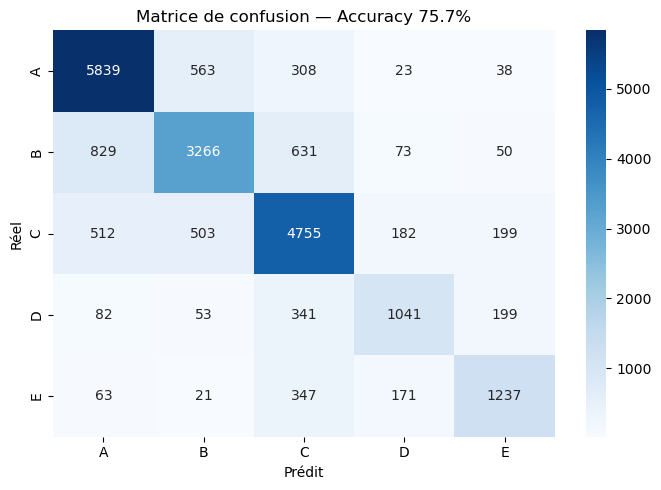

In [6]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['A','B','C','D','E'],
            yticklabels=['A','B','C','D','E'], ax=ax)
ax.set_xlabel('Prédit')
ax.set_ylabel('Réel')
ax.set_title(f'Matrice de confusion — Accuracy {acc:.1%}')
plt.tight_layout()
plt.show()

## 5. Importance des features

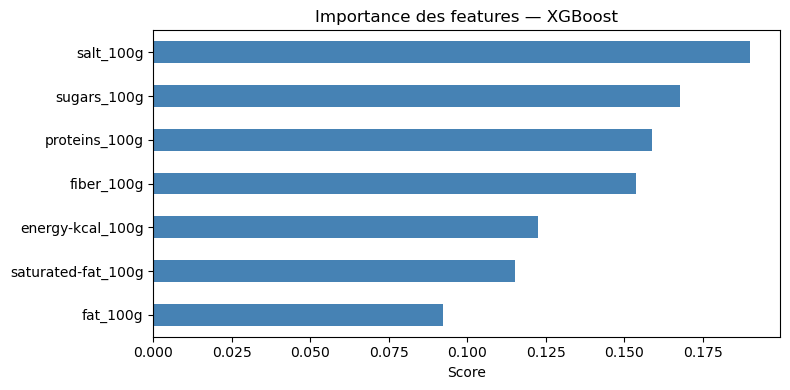

In [7]:
importance = pd.Series(model.feature_importances_, index=features_utilisees).sort_values()
fig, ax = plt.subplots(figsize=(8, 4))
importance.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Importance des features — XGBoost')
ax.set_xlabel('Score')
plt.tight_layout()
plt.show()

## 6. Export du modèle

In [8]:
joblib.dump({'model': model, 'label_encoder': le, 'features': features_utilisees}, MODEL_PATH)
print(f'Modèle exporté : {MODEL_PATH}')

Modèle exporté : ..\models\nutriscore_xgb.pkl
